# 09. Predictive surprise with a future-mask-trained S-JEPA predictor

A predictor trained to fill spatially scattered joints has not learned the same task as causal
future prediction. Therefore this notebook permits a positive world-model claim only for a
**separately trained future-mask checkpoint**. Applying a future suffix to the ordinary spatial-
infilling predictor is retained solely as an explicitly out-of-distribution (OOD) negative control.

Horizon selection is label-free and validation-only. Test surprise is computed after the horizon
is frozen, averaged within source video, and then analyzed with equal source weight.

**Research use only.** Surprise is not a diagnosis or validated biomarker.


In [1]:
from pathlib import Path
import hashlib
import json
import os
import sys

import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, SVG, display


def find_experiment_dir(start=None):
    start = Path(start or Path.cwd()).resolve()
    candidates = []
    if os.getenv("ALEXPOSE_ROOT"):
        root = Path(os.environ["ALEXPOSE_ROOT"]).expanduser().resolve()
        candidates += [root, root / "experiments" / "sjepa" / "gavd5-drift"]
    for base in [start, *start.parents]:
        candidates += [base, base / "experiments" / "sjepa" / "gavd5-drift"]
    for candidate in candidates:
        if (candidate / "pyproject.toml").is_file() and (candidate / "neurips-brain-body").is_dir():
            return candidate
    raise FileNotFoundError("Set ALEXPOSE_ROOT or start Jupyter in gavd5-drift.")


EXPERIMENT_DIR = find_experiment_dir()
NOTEBOOK_DIR = EXPERIMENT_DIR / "neurips-brain-body"


# Use the same experiment-level configuration contract as notebooks 01-02.
# Existing process variables win, so CI and explicit shell overrides remain
# authoritative while an interactive Jupyter kernel still sees `.env`.
try:
    from dotenv import load_dotenv
    load_dotenv(EXPERIMENT_DIR / ".env", override=False)
except ImportError:
    pass
MODE = os.getenv("GAVD_MODE", "real").strip().lower()
if MODE not in {"smoke", "real"}:
    raise ValueError("GAVD_MODE must be 'smoke' or 'real'.")
ARTIFACT_ROOT = Path(os.getenv("GAVD_ARTIFACT_DIR", EXPERIMENT_DIR / "work" / "artifacts")).expanduser()
ARTIFACT_DIR = ARTIFACT_ROOT / MODE
POSE_DIR = ARTIFACT_DIR / "poses"
AUGMENTED_POSE_DIR = ARTIFACT_DIR / "poses_augmented"
AUGMENTED_REPORT = ARTIFACT_DIR / "augmented_pose_extraction_report.csv"
PROTOCOL_DIR = ARTIFACT_DIR / "evaluation_protocol"
OUTER_FOLD = int(os.getenv("SJEPA_OUTER_FOLD", "0"))
MODEL_SEED = int(os.getenv("SJEPA_MODEL_SEED", "20260904"))
CONTRACT_VERSION = "sjepa_fold_contract_v2"
INCLUDE_AUGMENTED_NORMAL = False

sys.path.insert(0, str(NOTEBOOK_DIR))
from evaluation_protocol import (
    attach_pose_qc_eligibility,
    SPLIT_VERSION,
    expand_split,
    manifest_fingerprint,
    split_fingerprint,
    validate_split_registry,
)


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def show_protocol_figure():
    path = EXPERIMENT_DIR / "images" / "22_inductive_source_split.svg"
    if not path.is_file():
        raise FileNotFoundError(f"Missing protocol figure: {path}")
    display(SVG(filename=str(path)))


print(f"mode={MODE}; outer_fold={OUTER_FOLD}; seed={MODEL_SEED}")
print(f"artifact root: {ARTIFACT_DIR}")


mode=real; outer_fold=0; seed=42
artifact root: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real


In [2]:
BLAZEPOSE_33 = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER",
    "RIGHT_EYE_INNER", "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR",
    "RIGHT_EAR", "MOUTH_LEFT", "MOUTH_RIGHT", "LEFT_SHOULDER",
    "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW", "LEFT_WRIST",
    "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP",
    "RIGHT_HIP", "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE",
    "RIGHT_ANKLE", "LEFT_HEEL", "RIGHT_HEEL", "LEFT_FOOT_INDEX",
    "RIGHT_FOOT_INDEX",
]
MASK_KEYPOINTS = [11, 12, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]
CONDITIONS = ["normal", "parkinsons", "stroke", "myopathic", "cerebralpalsy"]


In [3]:
import copy
import math
import torch
from torch import nn


class SkeletonPatchEncoder(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames = frames
        self.joints = joints
        self.coordinate_dim = coordinate_dim
        self.segment_length = segment_length
        self.segments = frames // segment_length
        self.embed_dim = embed_dim
        self.patch_embed = nn.Linear(segment_length * coordinate_dim, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, embed_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch, frames, joints, channels = x.shape
        expected = (self.frames, self.joints, self.coordinate_dim)
        if (frames, joints, channels) != expected:
            raise ValueError(f"Expected [B, {expected}], received {x.shape}")
        patches = x.reshape(
            batch, self.segments, self.segment_length, joints, channels
        )
        patches = patches.permute(0, 1, 3, 2, 4).contiguous()
        return patches.flatten(3)

    def positioned_tokens(self, x):
        tokens = self.patch_embed(self.patchify(x))
        return (
            tokens
            + self.time_pos[None, :, None, :]
            + self.joint_pos[None, None, :, :]
        )

    def forward(self, x, keep_mask=None):
        tokens = self.positioned_tokens(x)
        batch = len(tokens)
        flat = tokens.reshape(batch, self.segments * self.joints, self.embed_dim)
        if keep_mask is not None:
            keep_mask = keep_mask.reshape(batch, -1)
            kept_per_sample = keep_mask.sum(dim=1)
            if not torch.equal(kept_per_sample, kept_per_sample[:1].expand_as(kept_per_sample)):
                raise ValueError("Each sample must keep the same number of tokens")
            flat = flat[keep_mask].reshape(batch, int(kept_per_sample[0]), self.embed_dim)
        return self.norm(self.blocks(flat))


class SkeletonPredictor(nn.Module):
    def __init__(
        self,
        segments,
        joints,
        encoder_dim=64,
        predictor_dim=64,
        depth=2,
        heads=4,
        dropout=0.0,
    ):
        super().__init__()
        self.segments = segments
        self.joints = joints
        self.encoder_to_predictor = nn.Linear(encoder_dim, predictor_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, predictor_dim))
        nn.init.normal_(self.mask_token, std=0.02)
        self.time_pos = nn.Parameter(torch.randn(segments, predictor_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(joints, predictor_dim) * 0.02)
        layer = nn.TransformerEncoderLayer(
            d_model=predictor_dim,
            nhead=heads,
            dim_feedforward=predictor_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm = nn.LayerNorm(predictor_dim)
        self.output = nn.Linear(predictor_dim, encoder_dim)

    def forward(self, visible_features, target_mask):
        batch = len(visible_features)
        target_mask = target_mask.reshape(batch, self.segments * self.joints)
        visible_mask = ~target_mask
        visible = self.encoder_to_predictor(visible_features)
        full = self.mask_token.expand(
            batch, self.segments * self.joints, -1
        ).clone()
        full[visible_mask] = visible.reshape(-1, visible.shape[-1])
        positions = (
            self.time_pos[:, None, :] + self.joint_pos[None, :, :]
        ).reshape(1, self.segments * self.joints, -1)
        full = full + positions
        predicted = self.output(self.norm(self.blocks(full)))
        return predicted[target_mask].reshape(batch, -1, predicted.shape[-1])


class SJEPAGait(nn.Module):
    def __init__(
        self,
        frames=64,
        joints=33,
        coordinate_dim=3,
        segment_length=4,
        embed_dim=64,
        encoder_depth=2,
        predictor_depth=2,
        heads=4,
    ):
        super().__init__()
        self.view_encoder = SkeletonPatchEncoder(
            frames, joints, coordinate_dim, segment_length,
            embed_dim, encoder_depth, heads,
        )
        self.target_encoder = copy.deepcopy(self.view_encoder)
        for parameter in self.target_encoder.parameters():
            parameter.requires_grad_(False)
        self.predictor = SkeletonPredictor(
            self.view_encoder.segments,
            joints,
            embed_dim,
            embed_dim,
            predictor_depth,
            heads,
        )
        self.register_buffer("target_center", torch.zeros(embed_dim))

    def forward(self, view, target, target_mask):
        visible_features = self.view_encoder(view, keep_mask=~target_mask)
        predicted = self.predictor(visible_features, target_mask)
        with torch.no_grad():
            all_targets = self.target_encoder(target)
            flat_mask = target_mask.reshape(len(target), -1)
            selected = all_targets[flat_mask].reshape(
                len(target), -1, all_targets.shape[-1]
            )
        return predicted, selected

    @torch.no_grad()
    def update_target(self, momentum):
        for target_parameter, view_parameter in zip(
            self.target_encoder.parameters(), self.view_encoder.parameters()
        ):
            target_parameter.mul_(momentum).add_(
                view_parameter, alpha=1.0 - momentum
            )

    @torch.no_grad()
    def update_center(self, targets, beta=0.9):
        batch_center = targets.mean(dim=(0, 1))
        self.target_center.mul_(beta).add_(batch_center, alpha=1.0 - beta)


In [4]:
def interpolate_low_visibility(sequence, threshold=0.45, max_gap=4):
    # Fill only short internal gaps and preserve the original validity mask.
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
        raise ValueError(f"Expected [T, 33, 4], received {sequence.shape}")
    visibility = np.nan_to_num(sequence[..., 3], nan=0.0)
    finite = np.isfinite(sequence[..., :3]).all(axis=-1)
    valid = (visibility >= threshold) & finite
    filled = valid.copy()
    for joint in range(33):
        observed = np.flatnonzero(valid[:, joint])
        for left, right in zip(observed[:-1], observed[1:]):
            gap = int(right - left - 1)
            if not 0 < gap <= max_gap:
                continue
            fraction = (
                np.arange(1, gap + 1, dtype=np.float32) / (gap + 1)
            )[:, None]
            sequence[left + 1:right, joint, :3] = (
                sequence[left, joint, :3][None, :] * (1.0 - fraction)
                + sequence[right, joint, :3][None, :] * fraction
            )
            filled[left + 1:right, joint] = True
        sequence[~filled[:, joint], joint, :3] = np.nan
    sequence[..., 3] = visibility
    return sequence, valid


def center_and_scale(sequence, eps=1e-6):
    sequence = np.asarray(sequence, dtype=np.float32).copy()
    xyz = sequence[..., :3]
    left_hip, right_hip = xyz[:, 23], xyz[:, 24]
    left_ok = np.isfinite(left_hip).all(axis=1)
    right_ok = np.isfinite(right_hip).all(axis=1)
    pelvis = np.full((len(xyz), 3), np.nan, dtype=np.float32)
    pelvis[left_ok & right_ok] = 0.5 * (
        left_hip[left_ok & right_ok] + right_hip[left_ok & right_ok]
    )
    pelvis[left_ok & ~right_ok] = left_hip[left_ok & ~right_ok]
    pelvis[right_ok & ~left_ok] = right_hip[right_ok & ~left_ok]
    pelvis_ok = np.isfinite(pelvis).all(axis=1)
    fallback = np.median(pelvis[pelvis_ok], axis=0) if pelvis_ok.any() else np.zeros(3)
    pelvis[~np.isfinite(pelvis).all(axis=1)] = fallback
    xyz = xyz - pelvis[:, None, :]
    shoulder_width = np.linalg.norm(xyz[:, 11, :2] - xyz[:, 12, :2], axis=-1)
    hip_width = np.linalg.norm(xyz[:, 23, :2] - xyz[:, 24, :2], axis=-1)
    body_scale = np.nanmedian(np.maximum(shoulder_width, hip_width))
    if not np.isfinite(body_scale) or body_scale < eps:
        body_scale = 1.0
    sequence[..., :3] = np.nan_to_num(
        xyz / body_scale, nan=0.0, posinf=0.0, neginf=0.0
    )
    return np.nan_to_num(sequence, nan=0.0, posinf=0.0, neginf=0.0)


def temporal_resize(array, frames):
    array = np.asarray(array)
    if len(array) == frames:
        return array.copy()
    if len(array) < 2:
        return np.repeat(array, frames, axis=0)
    old_t = np.linspace(0.0, 1.0, len(array))
    new_t = np.linspace(0.0, 1.0, frames)
    flat = array.reshape(len(array), -1)
    resized = np.stack(
        [np.interp(new_t, old_t, flat[:, i]) for i in range(flat.shape[1])],
        axis=1,
    )
    return resized.reshape(frames, *array.shape[1:]).astype(array.dtype)


def prepare_sequence(sequence, frames=64, visibility_threshold=0.45, max_gap=4):
    cleaned, valid = interpolate_low_visibility(
        sequence, visibility_threshold, max_gap=max_gap
    )
    cleaned = center_and_scale(cleaned)
    cleaned = temporal_resize(cleaned, frames)
    valid = temporal_resize(valid.astype(np.float32), frames) >= 0.5
    return cleaned[..., :3].astype(np.float32), valid.astype(bool)


In [5]:
def pose_records_from_cache(pose_dir=POSE_DIR, conditions=CONDITIONS):
    records = []
    for condition in conditions:
        folder = Path(pose_dir) / condition
        for path in sorted(folder.glob("*.npz")):
            data = np.load(path, allow_pickle=False)
            required = {
                "sequence", "sequence_id", "video_id", "condition",
                "frame_numbers", "crop_bounds", "fps", "source_csv",
                "source_video", "pose_model", "pose_model_sha256",
                "extraction_version",
            }
            missing = required.difference(data.files)
            if missing:
                raise ValueError(
                    f"Stale pose cache {path} is missing {sorted(missing)}. "
                    "Re-extract it with notebook 02."
                )
            sequence = data["sequence"].astype(np.float32)
            if sequence.ndim != 3 or sequence.shape[1:] != (33, 4):
                raise ValueError(f"Bad pose shape in {path}: {sequence.shape}")
            stored = str(data["condition"].item())
            if stored != condition:
                raise ValueError(
                    f"Pose condition {stored} does not match folder {condition}"
                )
            records.append({
                "condition": condition,
                "sequence_id": str(data["sequence_id"].item()),
                "video_id": str(data["video_id"].item()),
                "source_video": str(data["source_video"].item()),
                "fps": float(data["fps"].item()),
                "sequence": sequence,
                "path": str(path),
            })
    return records


def load_records_for_mode(conditions=CONDITIONS, frames=64):
    if MODE == "smoke":
        raise NotImplementedError("This notebook is designed for the real corpus.")
    records = pose_records_from_cache(conditions=conditions)
    counts = pd.Series([r["condition"] for r in records]).value_counts()
    missing = [c for c in conditions if counts.get(c, 0) == 0]
    if missing:
        raise FileNotFoundError(
            f"Real mode requires cached pose sequences for {missing}. Run notebook 02 first."
        )
    print(f"Real pose corpus: {len(records)} sequences")
    return records


def augmented_normal_records(pose_dir=AUGMENTED_POSE_DIR):
    if not INCLUDE_AUGMENTED_NORMAL or MODE != "real":
        return []
    folder = Path(pose_dir) / "normal"
    if not folder.exists():
        raise FileNotFoundError(
            f"SJEPA_INCLUDE_AUGMENTED_NORMAL is set but {folder} is missing."
        )
    report = pd.read_csv(AUGMENTED_REPORT)
    candidates = report[
        ~report["status"].astype(str).str.startswith("error")
    ].copy()
    candidates["accepted"] = (
        pd.to_numeric(candidates["neuro_observed"], errors="coerce") >= 0.45
    )
    selected_ids = set(
        candidates.loc[candidates["accepted"], "sequence_id"].astype(str)
    )
    available = {path.stem: path for path in folder.glob("*.npz")}
    missing_selected = sorted(selected_ids.difference(available))
    if missing_selected:
        raise FileNotFoundError(
            f"Accepted augmented pose files are missing: {missing_selected}"
        )
    records = []
    for sequence_id in sorted(selected_ids):
        path = available[sequence_id]
        data = np.load(path, allow_pickle=False)
        records.append({
            "condition": "normal",
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "source_video": str(data["source_video"].item()),
            "fps": float(data["fps"].item()),
            "cohort": "augmented_normal",
            "sequence": data["sequence"].astype(np.float32),
            "path": str(path),
        })
    return records


## Frozen source-disjoint evaluation map

The vector diagram below is the governing contract, not decoration: every YouTube source is assigned
to exactly one role within a fold. Encoder fitting uses **train** only; model and probe choices use
**validation** only; **test** is opened once after every choice is frozen. Sequence rows from the same
upload can never straddle roles.


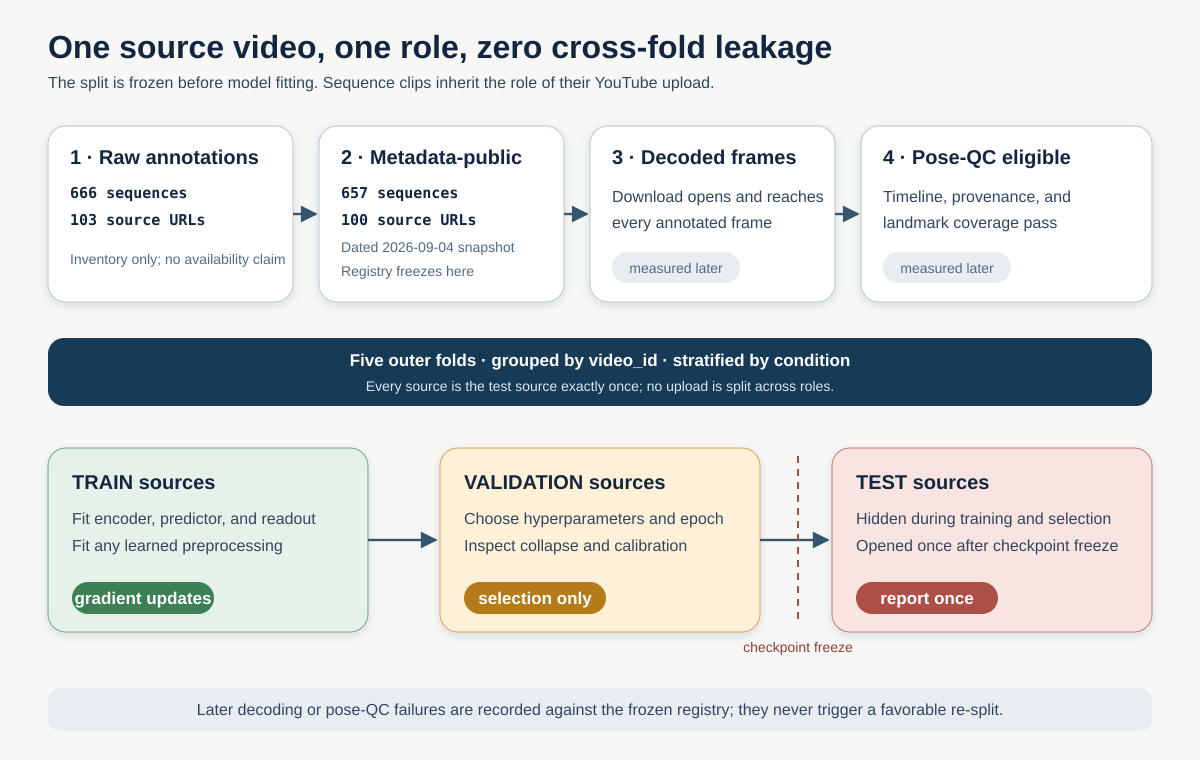

In [6]:
show_protocol_figure()


## Require a separately future-mask-trained fold checkpoint

`SJEPA_FUTURE_OBJECTIVE` defaults to `jepa_vicreg_future_mask`. Its objective metadata must declare
`mask_geometry` as `future`, `future_suffix`, or `causal_future`. The standard `jepa_vicreg`
checkpoint, when available, is loaded under a different hash only for the OOD control. If the
future-trained artifact is absent, the notebook stops cleanly at `BLOCKED`.

The fold-local pose-QC ledger is attached through the same hash-bound contract used by notebooks 04-06. Inventory extras and decoded-ineligible manifest placeholders are excluded before role sets are compared with checkpoint evidence.


## How to read the progress display

Five stages validate the protocol, require a separately future-mask-trained
checkpoint, select the horizon on validation sources, evaluate the frozen
horizon once on test sources, and persist the report. Missing prerequisites
produce an explicit not-run terminal state. The positive world-model gate, not
progress completion, determines whether a forecasting claim is licensed.


In [7]:
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))
from notebook_progress import NotebookTaskProgress

surprise_progress = NotebookTaskProgress(
    'Predictive-surprise workflow progress',
    "stage",
    refresh_seconds=0.5,
)
surprise_progress.start(5, profile=MODE)

with surprise_progress.unit(1, "Validate the protocol-v2 bundle"):
    MANIFEST_PATH = PROTOCOL_DIR / "eligible_sequence_manifest.csv"
    REGISTRY_PATH = PROTOCOL_DIR / "source_split_registry.csv"
    CONTRACT_PATH = PROTOCOL_DIR / "source_split_contract.json"
    POSE_QC_PATH = PROTOCOL_DIR / f"pose_qc_eligibility_outer_fold_{OUTER_FOLD}.csv"
    BLOCKED_REASON = None

    missing_protocol = [p for p in [MANIFEST_PATH, REGISTRY_PATH, CONTRACT_PATH] if not p.is_file()]
    if missing_protocol:
        BLOCKED_REASON = (
            "protocol-v2 bundle is absent: " + ", ".join(str(p) for p in missing_protocol)
            + ". Run notebooks 01–02 before this diagnostic."
        )
    else:
        protocol_manifest = pd.read_csv(MANIFEST_PATH)
        source_registry = pd.read_csv(REGISTRY_PATH)
        split_contract = json.loads(CONTRACT_PATH.read_text(encoding="utf-8"))
        validate_split_registry(source_registry, protocol_manifest)
        MANIFEST_SHA256 = manifest_fingerprint(protocol_manifest)
        SPLIT_SHA256 = split_fingerprint(source_registry)
        if split_contract.get("split_version") != SPLIT_VERSION:
            raise ValueError("Protocol bundle is not source-constrained split v2.")
        if split_contract.get("manifest_sha256") != MANIFEST_SHA256:
            raise ValueError("Manifest hash does not match source_split_contract.json.")
        if split_contract.get("split_sha256") != SPLIT_SHA256:
            raise ValueError("Split hash does not match source_split_contract.json.")
        if OUTER_FOLD not in set(source_registry["outer_fold"].astype(int)):
            raise ValueError(f"Unknown outer fold {OUTER_FOLD}.")
        fold_manifest = expand_split(protocol_manifest, source_registry, OUTER_FOLD)
        role_video_ids = {
            role: set(fold_manifest.loc[fold_manifest["role"].eq(role), "video_id"].astype(str))
            for role in ("train", "validation", "test")
        }
        role_sequence_ids = {
            role: set(fold_manifest.loc[fold_manifest["role"].eq(role), "sequence_id"].astype(str))
            for role in ("train", "validation", "test")
        }
        if any(role_video_ids[a] & role_video_ids[b] for a, b in [
            ("train", "validation"), ("train", "test"), ("validation", "test")
        ]):
            raise AssertionError("Source leakage in the frozen protocol bundle.")

    if BLOCKED_REASON:
        display(Markdown(f"> **BLOCKED — no results computed.** {BLOCKED_REASON}"))
    else:
        display(pd.DataFrame({
            role: {
                "sources": len(role_video_ids[role]),
                "sequences": len(role_sequence_ids[role]),
            }
            for role in ("train", "validation", "test")
        }).T)


,sources,sequences
train,60,392
validation,20,134
test,20,131


In [8]:
REQUIRED_ACCESS_KEYS = {
    "contract_version", "mode", "outer_fold", "model_seed", "objective",
    "manifest_sha256", "split_sha256", "split_version", "role_video_ids",
    "role_sequence_ids", "model_config", "model_state", "mask_keypoints",
    "encoder_fit_video_ids", "encoder_fit_sequence_ids",
    "checkpoint_selection_video_ids", "checkpoint_selection_sequence_ids",
    "test_tensors_loaded", "tensor_access_log",
}


def checkpoint_paths(objective_name):
    stem = f"sjepa_outer_fold_{OUTER_FOLD}_seed_{MODEL_SEED}_{objective_name}"
    folder = ARTIFACT_DIR / "checkpoints"
    return folder / f"{stem}.pt", folder / f"{stem}.json"


def _as_role_sets(value):
    return {role: set(map(str, value[role])) for role in ("train", "validation", "test")}


def load_verified_checkpoint(objective_name, *, require_future_mask=False):
    checkpoint_path, sidecar_path = checkpoint_paths(objective_name)
    if not checkpoint_path.is_file() or not sidecar_path.is_file():
        return None, None, (
            f"missing fold-local checkpoint bundle {checkpoint_path.name} / {sidecar_path.name}; "
            "run notebook 04 for this fold, seed, and objective"
        )
    sidecar = json.loads(sidecar_path.read_text(encoding="utf-8"))
    actual_sha = sha256_file(checkpoint_path)
    if sidecar.get("checkpoint_sha256") != actual_sha:
        raise ValueError(f"Checkpoint SHA mismatch: {checkpoint_path}")
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    missing = REQUIRED_ACCESS_KEYS.difference(checkpoint)
    if missing:
        raise ValueError(f"Checkpoint lacks protocol-v2 access evidence: {sorted(missing)}")
    for key in [
        "contract_version", "mode", "outer_fold", "model_seed", "manifest_sha256",
        "split_sha256", "split_version", "role_video_ids", "role_sequence_ids",
        "encoder_fit_video_ids", "encoder_fit_sequence_ids",
        "checkpoint_selection_video_ids", "checkpoint_selection_sequence_ids",
        "test_tensors_loaded",
    ]:
        if sidecar.get(key) != checkpoint.get(key):
            raise ValueError(f"Sidecar/checkpoint disagreement for {key}")
    expected = {
        "contract_version": CONTRACT_VERSION,
        "mode": MODE,
        "outer_fold": OUTER_FOLD,
        "model_seed": MODEL_SEED,
        "manifest_sha256": MANIFEST_SHA256,
        "split_sha256": SPLIT_SHA256,
        "split_version": SPLIT_VERSION,
    }
    for key, value in expected.items():
        if checkpoint.get(key) != value:
            raise ValueError(f"Checkpoint {key}={checkpoint.get(key)!r}; expected {value!r}")
    if not POSE_QC_PATH.is_file():
        return None, None, f"missing fold pose-QC ledger: {POSE_QC_PATH}"
    pose_qc = pd.read_csv(POSE_QC_PATH)
    qc_rows = attach_pose_qc_eligibility(
        fold_manifest,
        pose_qc,
        outer_fold=OUTER_FOLD,
        manifest_sha256=MANIFEST_SHA256,
        split_sha256=SPLIT_SHA256,
    )
    eligible = qc_rows.loc[qc_rows["pose_qc_eligible"]].copy()
    qc_video_ids = {
        role: set(eligible.loc[eligible["role"].eq(role), "video_id"].astype(str))
        for role in ("train", "validation", "test")
    }
    qc_sequence_ids = {
        role: set(eligible.loc[eligible["role"].eq(role), "sequence_id"].astype(str))
        for role in ("train", "validation", "test")
    }
    checkpoint_videos = _as_role_sets(checkpoint["role_video_ids"])
    checkpoint_sequences = _as_role_sets(checkpoint["role_sequence_ids"])
    if checkpoint_videos != qc_video_ids or checkpoint_sequences != qc_sequence_ids:
        raise ValueError("Checkpoint roles differ from the hash-bound pose-QC ledger.")
    if any(not checkpoint_videos[role] <= role_video_ids[role] for role in checkpoint_videos):
        raise ValueError("Pose-QC video roles are not subsets of the frozen registry.")
    if any(not checkpoint_sequences[role] <= role_sequence_ids[role] for role in checkpoint_sequences):
        raise ValueError("Pose-QC sequence roles are not subsets of the frozen registry.")
    fit_videos = set(map(str, checkpoint["encoder_fit_video_ids"]))
    fit_sequences = set(map(str, checkpoint["encoder_fit_sequence_ids"]))
    selection_videos = set(map(str, checkpoint["checkpoint_selection_video_ids"]))
    selection_sequences = set(map(str, checkpoint["checkpoint_selection_sequence_ids"]))
    # A recorded test exposure is a hard failure, never a warning or BLOCKED result.
    if fit_videos & role_video_ids["test"] or fit_sequences & role_sequence_ids["test"]:
        raise AssertionError("LEAKAGE: encoder fitting saw outer-test IDs.")
    if checkpoint["test_tensors_loaded"] is not False:
        raise AssertionError("LEAKAGE: notebook 04 reports loading test tensors.")
    if not fit_videos <= role_video_ids["train"] or not fit_sequences <= role_sequence_ids["train"]:
        raise AssertionError("Encoder-fit IDs are not a subset of the training role.")
    if not selection_videos <= role_video_ids["validation"]:
        raise AssertionError("Checkpoint selection used sources outside validation.")
    if not selection_sequences <= role_sequence_ids["validation"]:
        raise AssertionError("Checkpoint selection used sequences outside validation.")
    objective = checkpoint["objective"]
    if objective.get("name") != objective_name:
        raise ValueError("Objective name does not match the requested artifact.")
    if require_future_mask:
        geometry = objective.get("mask_geometry", checkpoint.get("training_mask_geometry"))
        if geometry not in {"future", "future_suffix", "causal_future"}:
            raise ValueError(
                "Positive world-model evaluation requires a predictor trained with a future mask."
            )
    checkpoint["_path"] = str(checkpoint_path)
    checkpoint["_sha256"] = actual_sha
    checkpoint["_sidecar"] = sidecar
    return checkpoint, sidecar, None


class _FoldSkeletonEncoder(nn.Module):
    """Exact architecture serialized by protocol-v2 notebook 04.

    Diagnostic notebooks must instantiate the producer's architecture rather
    than reinterpret ``model_config`` through an older wrapper. Strict state
    loading below makes future architecture drift fail at the checkpoint gate.
    """

    def __init__(self, frames=32, segment_length=4, embed_dim=32, depth=1, heads=4):
        super().__init__()
        if frames % segment_length:
            raise ValueError("frames must be divisible by segment_length")
        self.frames, self.segment_length = frames, segment_length
        self.segments, self.embed_dim = frames // segment_length, embed_dim
        self.patch = nn.Linear(3, embed_dim)
        self.time_pos = nn.Parameter(torch.randn(self.segments, embed_dim) * 0.02)
        self.joint_pos = nn.Parameter(torch.randn(33, embed_dim) * 0.02)
        self.mask_token = nn.Parameter(torch.zeros(embed_dim))
        layer = nn.TransformerEncoderLayer(
            embed_dim, heads, embed_dim * 2, dropout=0.0,
            activation="gelu", batch_first=True, norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, depth)
        self.norm = nn.LayerNorm(embed_dim)

    def patchify(self, x):
        batch = len(x)
        return x.reshape(batch, self.segments, self.segment_length, 33, 3).mean(dim=2)

    def patch_valid(self, valid):
        batch = len(valid)
        return valid.reshape(batch, self.segments, self.segment_length, 33).all(dim=2)

    def forward(self, x, hidden=None):
        tokens = self.patch(self.patchify(x))
        if hidden is not None:
            tokens = torch.where(hidden[..., None], self.mask_token, tokens)
        tokens = tokens + self.time_pos[None, :, None, :] + self.joint_pos[None, None, :, :]
        shape = tokens.shape
        tokens = self.blocks(tokens.reshape(shape[0], shape[1] * shape[2], shape[3]))
        return self.norm(tokens).reshape(shape)


class _FoldSJEPAPredictor(nn.Module):
    def __init__(self, segments, embed_dim=32):
        super().__init__()
        self.position = nn.Parameter(torch.randn(segments, 33, embed_dim) * 0.02)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, embed_dim),
        )

    def forward(self, context_tokens, visible):
        weight = visible[..., None].float()
        context = (context_tokens * weight).sum((1, 2)) / weight.sum((1, 2)).clamp_min(1.0)
        return self.net(context[:, None, None, :] + self.position[None])


class _FoldSJEPA(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.view_encoder = _FoldSkeletonEncoder(**config)
        self.target_encoder = copy.deepcopy(self.view_encoder)
        self.predictor = _FoldSJEPAPredictor(
            self.view_encoder.segments, config["embed_dim"]
        )

    def forward(self, view, target, target_mask):
        # The diagnostics pass only a target mask, so every non-target token is
        # visible here. Pose-validity masks are applied again when metrics are
        # aggregated; this mirrors notebook 04's checkpointed predictor API.
        online = self.view_encoder(view, hidden=target_mask)
        predicted_all = self.predictor(online, ~target_mask)
        with torch.no_grad():
            target_all = self.target_encoder(target)
        batch, _, _, width = predicted_all.shape
        predicted = predicted_all[target_mask].reshape(batch, -1, width)
        targets = target_all[target_mask].reshape(batch, -1, width)
        return predicted, targets


def model_from_checkpoint(checkpoint):
    model = _FoldSJEPA(checkpoint["model_config"])
    states = checkpoint["model_state"]
    # Strict=True is intentional: checkpoint/consumer architecture mismatch is
    # a provenance failure, not a warning that should be partially loaded.
    model.view_encoder.load_state_dict(states["online_encoder"], strict=True)
    model.target_encoder.load_state_dict(states["target_encoder"], strict=True)
    model.predictor.load_state_dict(states["predictor"], strict=True)
    model.eval()
    return model


In [9]:
with surprise_progress.unit(2, "Verify separately trained future and spatial checkpoints"):
    FUTURE_OBJECTIVE = os.getenv("SJEPA_FUTURE_OBJECTIVE", "jepa_vicreg_future_mask")
    SPATIAL_OBJECTIVE = os.getenv("SJEPA_SPATIAL_OBJECTIVE", "jepa_vicreg")
    READY = False
    if not BLOCKED_REASON:
        future_checkpoint, future_sidecar, future_block = load_verified_checkpoint(
            FUTURE_OBJECTIVE, require_future_mask=True
        )
        if future_block:
            BLOCKED_REASON = (
                future_block + ". A spatial-infilling predictor is not a substitute for a "
                "future-mask-trained predictor."
            )
        else:
            future_model = model_from_checkpoint(future_checkpoint)
            spatial_checkpoint, spatial_sidecar, spatial_block = load_verified_checkpoint(SPATIAL_OBJECTIVE)
            spatial_model = None if spatial_block else model_from_checkpoint(spatial_checkpoint)
            if spatial_model is not None and spatial_checkpoint["_sha256"] == future_checkpoint["_sha256"]:
                raise ValueError("Future and spatial checkpoints must be separately trained artifacts.")
            config = future_checkpoint["model_config"]
            FRAMES = int(config["frames"])
            SEGMENTS = FRAMES // int(config["segment_length"])
            EMBED_DIM = int(config["embed_dim"])
            READY = True

    if BLOCKED_REASON:
        display(Markdown(f"> **BLOCKED — no world-model result exists.** {BLOCKED_REASON}"))
    else:
        print(f"verified separately future-mask-trained predictor: {future_checkpoint['_path']}")
        if spatial_model is None:
            print("spatial OOD negative control unavailable; positive future-model evaluation can proceed")
        else:
            print("spatial checkpoint loaded only for the explicitly OOD future-mask negative control")
if not READY:
    surprise_progress.finish_skipped(
        BLOCKED_REASON, status="Preflight complete — prerequisites unavailable"
    )


> **BLOCKED — no world-model result exists.** missing fold-local checkpoint bundle sjepa_outer_fold_0_seed_42_jepa_vicreg_future_mask.pt / sjepa_outer_fold_0_seed_42_jepa_vicreg_future_mask.json; run notebook 04 for this fold, seed, and objective. A spatial-infilling predictor is not a substitute for a future-mask-trained predictor.

In [10]:
def load_fold_records(checkpoint, allowed_roles=("train", "validation", "test")):
    allowed_roles = tuple(allowed_roles)
    if not set(allowed_roles) <= {"train", "validation", "test"}:
        raise ValueError(f"Unknown role request: {allowed_roles}")
    checkpoint_roles = _as_role_sets(checkpoint["role_sequence_ids"])
    wanted_by_role = {role: checkpoint_roles[role] for role in allowed_roles}
    wanted = set().union(*wanted_by_role.values())
    manifest_rows = protocol_manifest.set_index("sequence_id", drop=False)
    records = []
    for sequence_id in sorted(wanted):
        if sequence_id not in manifest_rows.index:
            raise ValueError(f"Checkpoint sequence is not in the frozen manifest: {sequence_id}")
        row = manifest_rows.loc[sequence_id]
        path = POSE_DIR / str(row["condition"]) / f"{sequence_id}.npz"
        if not path.is_file():
            raise FileNotFoundError(f"Missing pose-QC-eligible cache: {path}")
        data = np.load(path, allow_pickle=False)
        required = {"sequence", "sequence_id", "video_id", "condition", "fps", "frame_numbers"}
        missing = required.difference(data.files)
        if missing:
            raise ValueError(f"Pose cache {path} lacks {sorted(missing)}")
        observed = {
            "sequence_id": str(data["sequence_id"].item()),
            "video_id": str(data["video_id"].item()),
            "condition": str(data["condition"].item()),
        }
        expected = {
            "sequence_id": sequence_id,
            "video_id": str(row["video_id"]),
            "condition": str(row["condition"]),
        }
        if observed != expected:
            raise ValueError(f"Pose provenance mismatch in {path}: {observed} != {expected}")
        role = next(role for role, ids in wanted_by_role.items() if sequence_id in ids)
        records.append({
            **observed,
            "role": role,
            "fps": float(data["fps"].item()),
            "frame_numbers": data["frame_numbers"].astype(np.int64),
            "sequence": data["sequence"].astype(np.float32),
            "path": str(path),
        })
    return records


## Tune future horizon on validation sources

For each candidate horizon, the future-trained predictor and a copy-last latent baseline are
scored on validation sources. The label-free criterion is mean source-level cosine advantage over
copy-last. The best horizon is frozen before any test tensor is sliced.


In [11]:
def valid_patch_mask(validity):
    return validity.reshape(len(validity), SEGMENTS, FRAMES // SEGMENTS, 33).all(axis=2)


def future_mask(n, horizon):
    mask = np.zeros((n, SEGMENTS, 33), dtype=bool)
    mask[:, SEGMENTS - horizon:, MASK_KEYPOINTS] = True
    return mask


def future_cosine(model, arrays, valid_patch, horizon, batch_size=12):
    values = []
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(arrays[start:start + batch_size], dtype=torch.float32)
        mask_np = future_mask(len(batch), horizon)
        mask = torch.tensor(mask_np, dtype=torch.bool)
        with torch.no_grad():
            prediction, target = model(batch, batch, mask)
        cosine = torch.nn.functional.cosine_similarity(prediction, target, dim=-1).cpu().numpy()
        valid_selected = valid_patch[start:start + len(batch)][:, SEGMENTS - horizon:, MASK_KEYPOINTS]
        cosine = np.where(valid_selected.reshape(len(batch), -1), cosine, np.nan)
        values.append(np.nanmean(cosine, axis=1))
    return np.concatenate(values)


def copy_last_cosine(model, arrays, valid_patch, horizon, batch_size=12):
    values = []
    for start in range(0, len(arrays), batch_size):
        batch = torch.tensor(arrays[start:start + batch_size], dtype=torch.float32)
        with torch.no_grad():
            tokens = model.target_encoder(batch).reshape(len(batch), SEGMENTS, 33, EMBED_DIM)
        previous = tokens[:, SEGMENTS - horizon - 1, MASK_KEYPOINTS]
        future = tokens[:, SEGMENTS - horizon:, MASK_KEYPOINTS]
        cosine = torch.nn.functional.cosine_similarity(previous[:, None].expand_as(future), future, dim=-1)
        valid_selected = torch.tensor(
            valid_patch[start:start + len(batch)][:, SEGMENTS - horizon:, MASK_KEYPOINTS]
        )
        cosine = torch.where(valid_selected, cosine, torch.nan)
        values.append(torch.nanmean(cosine, dim=(1, 2)).cpu().numpy())
    return np.concatenate(values)


def source_equal_table(values, records):
    return pd.DataFrame({
        "video_id": [record["video_id"] for record in records],
        "condition": [record["condition"] for record in records],
        "value": values,
    }).groupby("video_id", as_index=False).agg(condition=("condition", "first"), value=("value", "mean"))


if not READY:
    print("SKIPPED: no future-mask scores were computed.")
else:
    with surprise_progress.unit(3, "Select the future horizon on validation sources"):
        validation_records = load_fold_records(
            future_checkpoint, allowed_roles=("validation",)
        )
        validation_prepared = [
            prepare_sequence(record["sequence"], frames=FRAMES) for record in validation_records
        ]
        validation_xyz = np.stack([item[0] for item in validation_prepared]).astype(np.float32)
        validation_valid = np.stack([item[1] for item in validation_prepared])
        validation_patches = valid_patch_mask(validation_valid)
        HORIZONS = [h for h in (2, 4, 8) if h < SEGMENTS]
        horizon_rows = []
        for horizon in HORIZONS:
            predicted = future_cosine(future_model, validation_xyz, validation_patches, horizon)
            copy_last = copy_last_cosine(future_model, validation_xyz, validation_patches, horizon)
            predicted_source = source_equal_table(predicted, validation_records)
            copy_source = source_equal_table(copy_last, validation_records)
            advantage = float(predicted_source["value"].mean() - copy_source["value"].mean())
            horizon_rows.append({
                "horizon": horizon,
                "validation_future_cosine": float(predicted_source["value"].mean()),
                "validation_copy_last_cosine": float(copy_source["value"].mean()),
                "validation_advantage": advantage,
            })
        validation_horizons = pd.DataFrame(horizon_rows)
        selected_horizon = int(validation_horizons.sort_values(
            ["validation_advantage", "horizon"], ascending=[False, True]
        ).iloc[0]["horizon"])
        display(validation_horizons)
        print("validation-selected horizon:", selected_horizon)


SKIPPED: no future-mask scores were computed.


## One held-out, source-level surprise evaluation

The test fold is evaluated once at the frozen horizon. `surprise = 1 − cosine`; sequence scores
are averaged within YouTube source before AUROC or mean comparisons. The spatial predictor's
future-mask score is named `..._OOD` in the table so it cannot be mistaken for forecasting.


In [12]:
from sklearn.metrics import roc_auc_score


if not READY:
    print("SKIPPED: outer test was not opened.")
else:
    with surprise_progress.unit(4, "Evaluate predictive surprise on test sources once"):
        # Test pose tensors are loaded only after the horizon is frozen on validation.
        test_records = load_fold_records(future_checkpoint, allowed_roles=("test",))
        test_prepared = [prepare_sequence(record["sequence"], frames=FRAMES) for record in test_records]
        test_xyz = np.stack([item[0] for item in test_prepared]).astype(np.float32)
        test_valid = np.stack([item[1] for item in test_prepared])
        test_patches = valid_patch_mask(test_valid)
        future_test = future_cosine(future_model, test_xyz, test_patches, selected_horizon)
        copy_test = copy_last_cosine(future_model, test_xyz, test_patches, selected_horizon)
        future_sources = source_equal_table(future_test, test_records).rename(columns={"value": "future_cosine"})
        copy_sources = source_equal_table(copy_test, test_records).rename(columns={"value": "copy_last_cosine"})
        test_sources = future_sources.merge(copy_sources[["video_id", "copy_last_cosine"]], on="video_id")
        test_sources["surprise"] = 1.0 - test_sources["future_cosine"]
        if spatial_model is not None:
            # Deliberate OOD negative control: this predictor learned spatial infilling, not forecasting.
            spatial_ood = future_cosine(spatial_model, test_xyz, test_patches, selected_horizon)
            spatial_sources = source_equal_table(spatial_ood, test_records).rename(
                columns={"value": "spatial_infilling_predictor_future_cosine_OOD"}
            )
            test_sources = test_sources.merge(
                spatial_sources[["video_id", "spatial_infilling_predictor_future_cosine_OOD"]],
                on="video_id",
            )
        normal = test_sources["condition"].eq("normal")
        auroc_rows = []
        for condition in CONDITIONS[1:]:
            subset = normal | test_sources["condition"].eq(condition)
            y = test_sources.loc[subset, "condition"].eq(condition).astype(int)
            auroc_rows.append({
                "condition": condition,
                "source_level_auroc": float(roc_auc_score(y, test_sources.loc[subset, "surprise"])),
                "sources": int(subset.sum()),
            })
        auroc_table = pd.DataFrame(auroc_rows)
        mean_advantage = float((test_sources["future_cosine"] - test_sources["copy_last_cosine"]).mean())
        positive_claim_gate = bool(mean_advantage > 0)
        display(test_sources)
        display(auroc_table)
        print(f"source-equal future-vs-copy advantage={mean_advantage:+.4f}")
        print("positive world-model gate:", "PASS" if positive_claim_gate else "FAIL")


SKIPPED: outer test was not opened.


In [13]:
if not READY:
    print("BLOCKED: no predictive-surprise report was written.")
else:
    with surprise_progress.unit(5, "Persist predictive-surprise evidence"):
        output_dir = ARTIFACT_DIR / "fold_evaluation" / f"outer_fold_{OUTER_FOLD}"
        output_dir.mkdir(parents=True, exist_ok=True)
        source_path = output_dir / f"predictive_surprise_test_sources_seed_{MODEL_SEED}.csv"
        report_path = output_dir / f"predictive_surprise_seed_{MODEL_SEED}.json"
        test_sources.to_csv(source_path, index=False)
        report = {
            "notebook": "09_predictive_surprise_world_model",
            "contract_version": CONTRACT_VERSION,
            "split_version": SPLIT_VERSION,
            "outer_fold": OUTER_FOLD,
            "manifest_sha256": MANIFEST_SHA256,
            "split_sha256": SPLIT_SHA256,
            "future_checkpoint_sha256": future_checkpoint["_sha256"],
            "future_training_mask": future_checkpoint["objective"].get("mask_geometry"),
            "spatial_ood_checkpoint_sha256": (
                None if spatial_model is None else spatial_checkpoint["_sha256"]
            ),
            "horizon_selection": validation_horizons.to_dict(orient="records"),
            "selected_horizon": selected_horizon,
            "test_unit": "source video; sequence surprises averaged within source",
            "test_future_vs_copy_advantage": mean_advantage,
            "positive_world_model_gate": positive_claim_gate,
            "auroc": auroc_table.to_dict(orient="records"),
            "claim_limit": (
                "Only the separately future-mask-trained predictor can support a positive forecasting claim. "
                "The spatial-infilling predictor under a future mask is an OOD negative control."
            ),
        }
        report_path.write_text(json.dumps(report, indent=2) + "\n", encoding="utf-8")
        print(f"wrote {report_path}")
    surprise_progress.complete(status="Predictive-surprise workflow complete")


BLOCKED: no predictive-surprise report was written.


## Claim boundary

A positive result requires the future-mask-trained model to outperform copy-last on source-equal
outer-test scores across the predeclared folds/seeds. The spatial OOD control can falsify an overly
broad claim, but it can never provide positive evidence for a learned world model.


## Visual predictive-surprise evidence state

If a separately future-mask-trained checkpoint exists, this cell plots validation horizon selection and source-level test AUROC. Otherwise it renders the missing prerequisite and sealed-test state instead of rebranding spatial infilling as forecasting.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


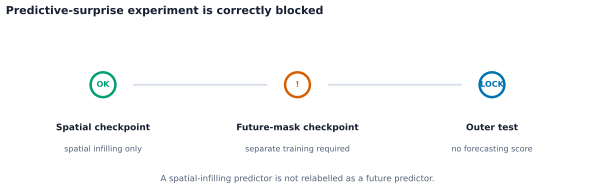

Notebook SVG: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\work\artifacts\real\figures\bbfm_predictive_surprise_v2.svg
Paper assets: C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_predictive_surprise_v2.svg C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_predictive_surprise_v2.png C:\Users\alexm\dev\alexpose\experiments\sjepa\gavd5-drift\docs\figures\bbfm_predictive_surprise_v2.pdf


In [14]:
# Paper and notebook rendering share this single source of truth.
from pathlib import Path as _VisualPath
import os as _visual_os
import sys as _visual_sys


def _find_visual_experiment(start=None):
    start = _VisualPath(start or _VisualPath.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "neurips-brain-body").is_dir() and (candidate / "data-gavd").is_dir():
            return candidate
        nested = candidate / "experiments" / "sjepa" / "gavd5-drift"
        if (nested / "neurips-brain-body").is_dir() and (nested / "data-gavd").is_dir():
            return nested
    raise FileNotFoundError("Could not locate experiments/sjepa/gavd5-drift")


_visual_experiment = _VisualPath(globals().get("EXPERIMENT_DIR", _find_visual_experiment())).resolve()
_visual_notebook_dir = _visual_experiment / "neurips-brain-body"
if str(_visual_notebook_dir) not in _visual_sys.path:
    _visual_sys.path.insert(0, str(_visual_notebook_dir))
try:
    from dotenv import load_dotenv as _visual_load_dotenv
    _visual_load_dotenv(_visual_experiment / ".env", override=False)
except ImportError:
    pass
_visual_mode = str(globals().get("MODE", _visual_os.getenv("GAVD_MODE", "real"))).strip().lower()
_visual_artifact_root = _VisualPath(
    _visual_os.getenv("GAVD_ARTIFACT_DIR", _visual_experiment / "work" / "artifacts")
).expanduser()
_visual_artifact_dir = _VisualPath(globals().get("ARTIFACT_DIR", _visual_artifact_root / _visual_mode))
_visual_outer_fold = int(globals().get("OUTER_FOLD", _visual_os.getenv("SJEPA_OUTER_FOLD", "0")))
_visual_seed = int(globals().get("MODEL_SEED", _visual_os.getenv("SJEPA_MODEL_SEED", "42")))
_visual_objective = str(globals().get("OBJECTIVE_NAME", _visual_os.getenv("SJEPA_OBJECTIVE", "jepa_vicreg")))

from scientific_visuals import render_notebook_summary

visual_summary = render_notebook_summary(
    "09",
    experiment_dir=_visual_experiment,
    artifact_dir=_visual_artifact_dir,
    outer_fold=_visual_outer_fold,
    model_seed=_visual_seed,
    objective=_visual_objective,
)
print("Notebook SVG:", visual_summary.notebook_svg)
print("Paper assets:", visual_summary.paper_svg, visual_summary.paper_png, visual_summary.paper_pdf)
